In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
import cv2

In [2]:
model = YOLO("yolov8m-seg.pt")

In [3]:
def segmentation(address):
    results = model.predict(address)
    result = results[0]
    masks = result.masks
    mask1 = masks[0].cpu()
    mask = mask1.data[0].numpy()
    color_image = cv2.imread(address)
    if color_image.shape[:2] != mask.shape:
        mask = cv2.resize(mask, (color_image.shape[1], color_image.shape[0]))
    mask_3d = cv2.merge([mask, mask, mask]).astype("uint8")
    colored_bird = color_image * mask_3d
    return colored_bird


In [29]:
def making_dataframe(root_dir):
    data = {"vector":[], "label":[]}
    for folder_name in os.listdir(root_dir):
        folder_path = os.path.join(root_dir, folder_name)
        if os.path.isdir(folder_path):
            for image_name in os.listdir(folder_path):
                image_path = os.path.join(folder_path, image_name)
                if os.path.isfile(image_path):
                    try:
                        image_vector = segmentation(image_path)
                        data["vector"].append(image_vector)
                        data["label"].append(folder_name[4:])
                    except Exception as e:
                        print(f"Error processing {image_path}: {e}")
    df = pd.DataFrame(data)
    df.to_pickle("image_vectors_labels.pkl")
    return df


In [30]:
df = making_dataframe("./images")


image 1/1 d:\Desktop\bird_classification\images\001.Black_footed_Albatross\Black_Footed_Albatross_0001_796111.jpg: 448x640 1 bird, 273.4ms
Speed: 5.0ms preprocess, 273.4ms inference, 6.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 d:\Desktop\bird_classification\images\001.Black_footed_Albatross\Black_Footed_Albatross_0002_55.jpg: 448x640 1 bird, 74.4ms
Speed: 5.5ms preprocess, 74.4ms inference, 4.6ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 d:\Desktop\bird_classification\images\001.Black_footed_Albatross\Black_Footed_Albatross_0003_796136.jpg: 480x640 1 bird, 35.6ms
Speed: 4.0ms preprocess, 35.6ms inference, 5.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 d:\Desktop\bird_classification\images\001.Black_footed_Albatross\Black_Footed_Albatross_0005_796090.jpg: 448x640 1 bird, 36.2ms
Speed: 3.0ms preprocess, 36.2ms inference, 3.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 d:\Desktop\bird_classification\images\001.Black

In [37]:
df = pd.read_pickle("image_vectors_labels.pkl")

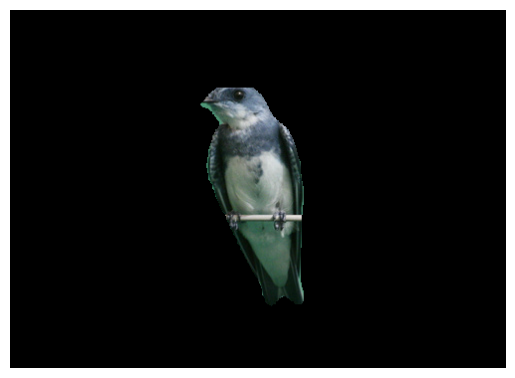

In [ ]:
plt.imshow(df["vector"][7895])
plt.axis('off')
plt.show()

In [13]:
print(df["vector"][0].shape)

(223, 320, 3)


In [33]:
print(df["vector"][5864].shape)

(375, 500, 3)
